In [3]:
from utils import *
import numpy as np

Degree of freedom:  2601


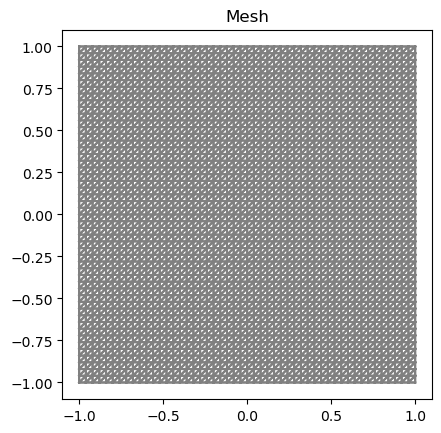

In [4]:
mesh = fn.RectangleMesh(fn.Point(-1, -1), fn.Point(1, 1), 50, 50)
fn.plot(mesh, title='Mesh')
V = fn.FunctionSpace(mesh, 'CG', 1)
print('Degree of freedom: ', V.dim())
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
M_matrix = fn.assemble(u_trial * u_test * fn.dx)
P_matrix = fn.assemble(u_trial * u_test * fn.dP)
P_solver = Operator2Solver(P_matrix)
fn.plot(mesh)

In [5]:
class Boundary(fn.SubDomain):
    def inside(self, x, on_boundary):
        left = x[0] < 0.75 + fn.DOLFIN_EPS and x[0] > -0.75 - fn.DOLFIN_EPS
        right = x[1] < 0.75 + fn.DOLFIN_EPS and x[1] > -0.75 - fn.DOLFIN_EPS
        return left and right

# Create a MeshFunction to mark boundaries
subdomains = fn.MeshFunction('size_t', mesh, mesh.topology().dim(), 0)
boundary = Boundary()
boundary.mark(subdomains, 1)  # Mark the left subdomain with the value 1

# Create a measure for the boundary
dx = fn.Measure('dx', domain=mesh, subdomain_data=subdomains)
ds = comp_dS(mesh, subdomains)

In [6]:
# Setting of the problem:
c = 300.    # Sound speed.

# Define simulation times:
T = 0.2
dt = 0.0005
simulation_times = np.arange(0., T + 0.5 * dt, dt)

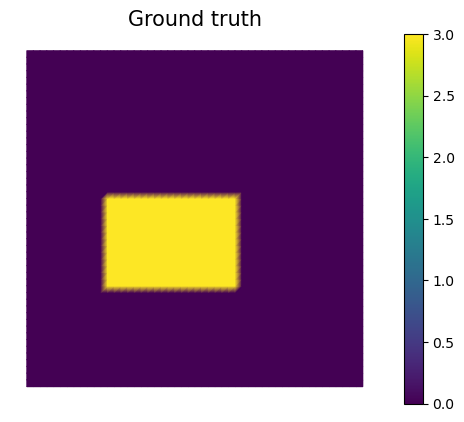

In [7]:
# Initial condition:
class RectangleExpression(fn.UserExpression):
    def eval(self, value, x):
        # Define the boundaries of the smaller L-shape within the square [-0.8, 0.8] x [-0.8, 0.8]
        if x[0] >= -0.55 - fn.DOLFIN_EPS and x[0] <= 0.25 + fn.DOLFIN_EPS and x[1] >= -0.4 - fn.DOLFIN_EPS and x[1] <= 0.125 + fn.DOLFIN_EPS:
            value[0] = 3.0  # Value inside the smaller L-shape
        # Define a circle with radius 0.5 and center (0.1, -0.1)
        # elif (x[0] - 0.25)**2 + (x[1] + 0.125)**2 <= 0.3**2:
        #     value[0] = 3.0  # Value inside the circle
        else:
            value[0] = 0.0  # Value outside the smaller L-shape

    def value_shape(self):
        return ()

ic_expr = RectangleExpression(element=V.ufl_element())
u_init = fn.interpolate(ic_expr, V).vector()
im = nb.plot(fn.Function(V, u_init), colorbar=False)
plt.colorbar(pad = 0.05)
plt.title('Ground truth', fontsize=15)
# Export plot to pdf with short marginal:
plt.savefig('ground_truth.pdf', bbox_inches='tight')
# Export:

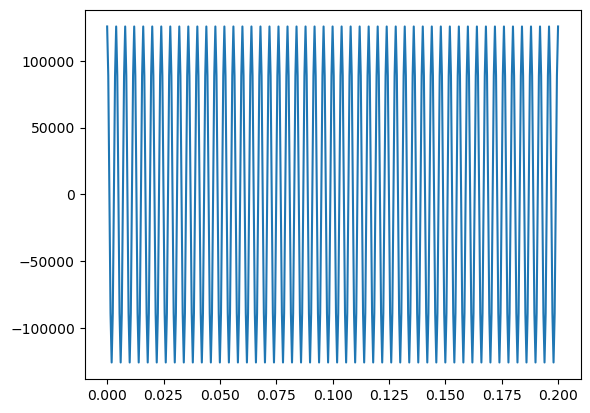

In [8]:
# Boundary condition:
bc = fn.DirichletBC(V, 0., "on_boundary")
bc.apply(u_init)
# Source term:
# x_opt = np.array([400., 0., 0., 0., 0.])
# x_opt = np.array([400., 0., 0., 0., 0.])
x_opt = np.array([0., 0., 0., 0., 80])
# x_opt = np.array([169.0322091 ,  88.21550748,  59.81361448,  45.65373375, 37.2849352])
# x_opt = np.array([169.19671285, 88.09726652, 59.78583995, 45.42995139, 37.49022929])
i_true_time_func = lambda t: (100 * np.pi * x_opt[0] * np.cos(100 * np.pi * t) 
                              + 200 * np.pi * x_opt[1] * np.cos(200 * np.pi * t)
                              + 300 * np.pi * x_opt[2] * np.cos(300 * np.pi * t)  
                              + 400 * np.pi * x_opt[3] * np.cos(400 * np.pi * t)
                              + 500 * np.pi * x_opt[4] * np.cos(500 * np.pi * t))
# i_true_time_func = lambda t: (100 * np.pi * x_opt_4[0] * np.cos(100 * np.pi * t) + 200 * np.pi * x_opt_4[1] * np.cos(200 * np.pi * t) + 300 * np.pi * x_opt_4[2] * np.cos(300 * np.pi * t) + 150 * np.pi * x_opt_4[3] * np.cos(150 * np.pi * t))
# i_true_time_int = i_true_time_int_func(simulation_times)
i_true_time = i_true_time_func(simulation_times)
f_true = space_time_mult(i_true_time, u_init, M_matrix, simulation_times)
# Zero vectors:
zero_vec = init_vector(M_matrix, 0)
zero_time_vec = init_time_vector(M_matrix, simulation_times, 0)
plt.plot(simulation_times, i_true_time)
# 

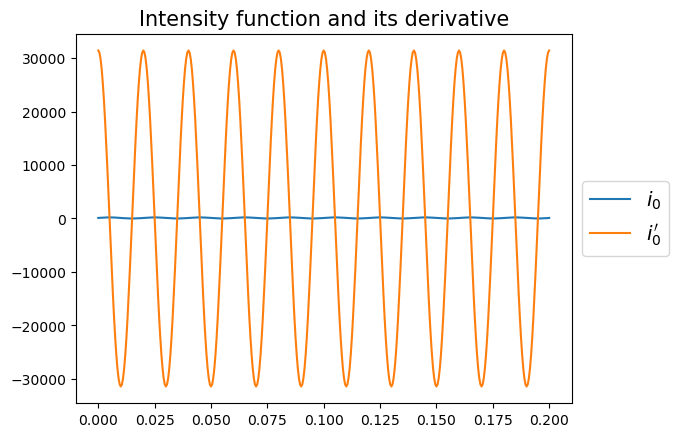

In [7]:
# Plot i:
i_int_func_time = lambda t: 100 * (np.sin(100 * np.pi * t) + 1)
i_int_time = i_int_func_time(simulation_times)
plt.plot(simulation_times, i_int_time)
# Plot i':
i_prime_func_time = lambda t: 100 * (100 * np.pi * np.cos(100 * np.pi * t))
i_prime_time = i_prime_func_time(simulation_times)
plt.plot(simulation_times, i_prime_time)
# Add bigger legend outside the plot:
plt.legend(['$i_0$', '$i_0\'$'], loc='center left', bbox_to_anchor=(1, 0.5), fontsize='x-large')
# Add title:
plt.title('Intensity function and its derivative', fontsize=15)
# Export plot to pdf with short marginal:
plt.savefig('opt_i_i_prime.pdf', bbox_inches='tight')


In [8]:
# Compute H1 norm:
from scipy.integrate import simps
result = simps(i_true_time * i_true_time, simulation_times)
print('H1 norm: ', result)

H1 norm:  1579136704.1742992


In [21]:
# Solve forward problem:
from WaveNewmarkFractional import *
c_expr = fn.Constant(c)
# alpha = 0.3
# alpha = 0.1
alpha = 0.3
b = (-(2 * c) / np.cos(np.pi * (alpha + 1)/ 2) )
print(b)
# b = 0.1321
# b = 0.3835
b = 0.1321
parameter = [c_expr, b, alpha]

1321.6135587511603


In [22]:
# Observation operator:
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
B_matrix = fn.assemble(fn.inner(u_trial('+'), u_test('+')) * ds(1))
_misfit = WaveSpaceTimeStateObservation(V, simulation_times, simulation_times, B_matrix)

In [23]:
f = lambda x, y:  0.01 * np.exp(-(np.abs(x[0] - y[0]) + np.abs(x[1] - y[1]))/0.1) 
grid = V.tabulate_dof_coordinates()
covariance = comp_covariance(grid, f)
eigvals, eigvecs = np.linalg.eigh(covariance)
prior_gaussian = GaussianPrior(V, covariance)
_prior = prior_gaussian

In [24]:
from WaveSolver import *
WaveNewModel = WaveInverseDamped(V, simulation_times, _misfit, _prior, parameter)

In [25]:
design = i_true_time
X_zero = WaveNewModel.generate_vector()
X_zero[PARAMETER][:] = u_init[:]
WaveNewModel.solveFwd(X_zero[STATE], X_zero, design)
WaveNewModel.misfit.p_obs = X_zero[STATE].copy()
WaveNewModel.misfit.noise_variance = 1e-2
parRandom.normal_perturb(WaveNewModel.misfit.noise_variance, WaveNewModel.misfit.p_obs)
print(WaveNewModel.cost(X_zero))

[17.404902422008508, 17.401050416338823, 0.003852005669685054]


In [14]:
# # Check computation:
# X_2 = WaveNewModel.generate_vector()
# # X_2[PARAMETER][:] = u_init[:]
# dm = init_vector(M_matrix, 0)
# du = init_vector(M_matrix, 0)
# dm[:] = 100 * np.random.normal(0, 100, dm.size())
# du[:] = 100 * np.random.normal(0, 100, du.size())
# bc.apply(dm)
# grad_misfit_1, grad_reg_1 = WaveNewModel.evalGradientFD(X_2, dm, design, 1e-8)
# grad_misfit_2, grad_reg_2 = WaveNewModel.evalGradientAD(X_2, dm, design)
# grad_misfit_3, grad_reg_3 = WaveNewModel.evalGradientADForward(X_2, dm, design)

In [15]:
# print('Gradient misfit: ', grad_misfit_1, grad_reg_1)
# print('Gradient misfit: ', grad_misfit_2, grad_reg_2)
# print('Gradient misfit: ', grad_misfit_3, grad_reg_3)

In [26]:
class Hessian_PAT:
    def __init__(self, model: WaveInverseDamped, design):
        self.model = model
        self.design = design
        self.variance = model.misfit.noise_variance
        
    def init_vector(self, x, dim):
        self.model.init_parameter(x)
        
    def mult(self, x, Hx):
        Hx.zero()
        X = self.model.generate_vector()
        X[PARAMETER][:] = x[:]
        obs = self.model.computeFwd(X, self.design)
        X_adj = self.model.computeAdj(obs, self.design)
        MX_adj = self.model.M_matrix * X_adj/self.variance
        Hx[:] = MX_adj[:]
        
    def inner(self, x, y):
        Hy = self.model.generate_vector(PARAMETER)
        Hy.zero()
        self.mult(y, Hy)
        return x.inner(Hy)

In [27]:
class Jacobian_PAT:
    def __init__(self, model, design):
        """
        Construct the Jacobian Operator
        """
        self.model = model
        self.design = design
        self.n_calls = 0

        self.RHS = model.generate_vector(STATE)
        self.u = model.generate_vector(STATE)
        self.p = model.generate_vector(ADJOINT)
        self.y_help = model.generate_vector(PARAMETER)
        self.M_matrix = self.model.M_matrix

        # Get RHS:
        X_zero = self.model.generate_vector()
        self.M_b = self.model.generate_vector(PARAMETER)
        self.model.solveAdj(X_zero[ADJOINT], X_zero)
        self.model.evalGradientParameter(X_zero, self.M_b, design)
        self.M_b *= -1

    def init_vector(self, x, dim):
        self.model.init_parameter(x)

    def mult(self, x, Jx):
        """
        Apply the Jacobian operator to the vector :code:`x`. Return the result in :code:`Jx`.
        """
        Jx.zero()
        x_state = self.model.generate_vector(STATE)
        x_adj = self.model.generate_vector(ADJOINT)
        X = [x_state, x, x_adj]
        self.model.solveFwd(x_state, X, design)
        self.model.solveAdj(x_adj, X)
        adj = self.model.computeAdj_old(X, design)
        M_adj = self.M_matrix * adj
        Jx[:] = M_adj[:]
        Jx.axpy(1., self.M_b)
        
        # Regularization term:
        self.model.applyR(x, self.y_help)
        Jx.axpy(1., self.y_help)

    def inner(self, x, y):
        """
        Return the inner product of x and y.
        """
        Jy = self.model.generate_vector(PARAMETER)
        Jy.zero()
        self.mult(y, Jy)
        return x.inner(Jy)

In [28]:
design = i_true_time
J_new = Jacobian_PAT(WaveNewModel, design)

In [30]:
k = 80
p = 20
i_ref_func = lambda t: 100 * np.pi * np.cos(100 * np.pi * t)
i_ref = i_ref_func(simulation_times)
H_new = Hessian_PAT(WaveNewModel, i_ref)
print( "Single Pass Algorithm. Requested eigenvectors: {0}; Oversampling {1}.".format(k,p))
prior_test = LaplacianPrior(V, 0.1, 8.)
Omega = MultiVector(X_zero[PARAMETER], k + p)
parRandom.normal(1., Omega)
lmbda, Z = singlePassG(H_new, prior_test.R, prior_test.Rsolver, Omega, k)
_posterior = GaussianLRPosterior(prior_test, lmbda, Z)

Single Pass Algorithm. Requested eigenvectors: 80; Oversampling 20.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forward problem.
Solve adjoint problem.
Solve forwar

In [ ]:
X_iter_2 = WaveNewModel.generate_vector()
solution = np.load('data/03_500_init_Ornstein.npy')
u_comp = init_vector_numpy(solution)
X_iter_2[PARAMETER][:] = u_comp[:]
SteinhaugSolver = CGSolverSteihaug()
SteinhaugSolver.set_operator(J_new)
SteinhaugSolver.set_preconditioner(_posterior.Hlr)
SteinhaugSolver.parameters["print_level"] = 1
SteinhaugSolver.parameters["rel_tolerance"] = 1e-3
SteinhaugSolver.parameters["abs_tolerance"] = 1e-2
SteinhaugSolver.parameters["max_iter"] = 1500
SteinhaugSolver.parameters["zero_initial_guess"] = False
SteinhaugSolver.solve(X_iter_2[PARAMETER], J_new.M_b)

In [20]:
WaveNewModel.solveFwd(X_iter_2[STATE], X_iter_2, design)
print(WaveNewModel.cost(X_iter_2))
# Compute L2 norm:
diff = X_iter_2[PARAMETER] - X_zero[PARAMETER]
norm = np.sqrt(diff.inner(M_matrix * diff))
norm_zero = np.sqrt(X_zero[PARAMETER].inner(M_matrix * X_zero[PARAMETER]))
print('Relative L2 error: ', norm/norm_zero)

[6.892604826778736, 6.678449282931908, 0.21415554384682822]
Relative L2 error:  0.4587013868899529


In [ ]:
# Export solution to numpy:
np.save('data/03_500_init_Ornstein.npy', X_iter_2[PARAMETER][:])